# Istanbul Housing Market Analysis
## Notebook 03 — Preprocessing & Baseline Regression Models

**Goal:** build a first modeling pipeline to predict `price` from the property features explored in Notebook 02 (EDA), compare a few baseline model families, and check the EDA hypotheses (e.g. location vs. size importance) against actual model behavior.

**Scope note:** unlike Notebooks 01-02, this notebook doesn't come from a pre-written detailed brief — it's a reasonable **first pass** based directly on the "Next Steps" conclusions of Notebook 02. Treat it as a solid starting point to refine (hyperparameter tuning, cross-validation, more careful missing-data handling) rather than a finished pipeline.

**Key decisions carried over from the EDA:**
- Target = `log1p(price)` — Notebook 02 found price strongly right-skewed (skewness ≈ 63).
- `price_per_sqm` is **never** used as a feature — it's derived from `price` (target leakage), confirmed in Notebook 01 and repeated throughout Notebook 02.
- Rows with `is_flagged_error=True` are excluded — Notebook 02 (Q5, Q21) showed these 67 rows (0.27%) distort relationships with `price` by up to 8x if left in.

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
PROCESSED_PATH = "../data/processed/istanbul_apartments_flagged.csv"

df = pd.read_csv(PROCESSED_PATH)
df = df.set_index("listing_id")

df_model = df[~df["is_flagged_error"]].copy()
print(f"Rows loaded: {len(df)}")
print(f"Rows after excluding is_flagged_error: {len(df_model)} ({(1 - len(df_model)/len(df))*100:.2f}% excluded)")


Rows loaded: 24767
Rows after excluding is_flagged_error: 24700 (0.27% excluded)


C:\Users\hafid\AppData\Local\Temp\ipykernel_10360\2700343273.py:3: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_PATH)


## 2. Feature Selection & Missing Data

Feature list based on the correlation/importance findings from Notebook 02 (Section 7 and Q5-Q19). `price_per_sqm` is excluded (target leakage). We check missingness on every candidate feature before deciding how to handle it.

In [3]:
numeric_features = ["net_sqm", "gross_sqm", "total_rooms", "floor", "total_floors",
                    "building_age", "bathroom_count", "maintenance_fee"]
categorical_features = ["district", "building_type", "floor_category", "furnished",
                        "is_in_complex", "building_condition", "credit_eligible", "deed_status"]

missing_report = df_model[numeric_features + categorical_features].isna().sum().sort_values(ascending=False)
missing_pct = (missing_report / len(df_model) * 100).round(2)
pd.DataFrame({"n_missing": missing_report, "pct_missing": missing_pct})


,n_missing,pct_missing
floor_category,17341,70.21
maintenance_fee,15725,63.66
building_type,14551,58.91
building_condition,13835,56.01
floor,1903,7.70
furnished,1072,4.34
bathroom_count,234,0.95
credit_eligible,7,0.03
total_floors,1,0.00
deed_status,1,0.00


**Important limitation to flag:** `floor_category` (~70% missing) and `maintenance_fee` (~64% missing) are very sparse. The imputation below (median for numeric, `"Unknown"` category for categorical) is a **simple, naive baseline choice** — not a considered missing-data strategy. Given how sparse these two columns are, a more careful next iteration should consider dropping them, or modeling "is missing" as its own signal, rather than blindly imputing. Flagging this now so it isn't forgotten later.

In [4]:
df_model_filled = df_model.copy()

for col in categorical_features:
    df_model_filled[col] = df_model_filled[col].fillna("Unknown")

for col in numeric_features:
    df_model_filled[col] = df_model_filled[col].fillna(df_model_filled[col].median())

print("Remaining missing values:", df_model_filled[numeric_features + categorical_features].isna().sum().sum())


Remaining missing values: 0


## 3. Encoding & Target Transform

Categorical variables are one-hot encoded (`district` has 38 levels, so this creates a fairly wide but sparse feature matrix — acceptable for tree-based models, less ideal for linear regression, noted as a limitation). Target is `log1p(price)` per the EDA's skew finding (Notebook 02, Q2/Q4).

In [5]:
df_model_filled["log_price"] = np.log1p(df_model_filled["price"])

X = pd.get_dummies(
    df_model_filled[numeric_features + categorical_features],
    columns=categorical_features,
    drop_first=True
)
y = df_model_filled["log_price"]

print("Feature matrix shape:", X.shape)


Feature matrix shape: (24700, 86)


## 4. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (19760, 86) | Test: (4940, 86)


## 5. Baseline Models

Three model families of increasing complexity: Linear Regression (interpretable baseline), Random Forest, and Gradient Boosting (both capable of capturing non-linear, interaction effects — relevant given Notebook 02 found some non-monotonic patterns, e.g. building age).

Evaluation is reported on **both** the log scale (what the models are actually trained on) and back-transformed to raw TRY (`np.expm1`) — the TRY-scale numbers are what matter for interpreting real-world prediction error, but the log-scale numbers are what's comparable across models during training.

In [7]:
results = []

def evaluate(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)
    preds_price = np.expm1(preds_log)
    actual_price = np.expm1(y_test)

    results.append({
        "model": name,
        "RMSE (log)": np.sqrt(mean_squared_error(y_test, preds_log)),
        "MAE (log)": mean_absolute_error(y_test, preds_log),
        "R2 (log)": r2_score(y_test, preds_log),
        "RMSE (TRY)": np.sqrt(mean_squared_error(actual_price, preds_price)),
        "MAE (TRY)": mean_absolute_error(actual_price, preds_price),
        "R2 (TRY)": r2_score(actual_price, preds_price),
    })
    return model


In [8]:
lr_model = evaluate(
    "Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)


In [9]:
rf_model = evaluate(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
)


In [10]:
gb_model = evaluate(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
    X_train, X_test, y_train, y_test
)


In [11]:
results_df = pd.DataFrame(results).set_index("model")
results_df


,RMSE (log),MAE (log),R2 (log),RMSE (TRY),MAE (TRY),R2 (TRY)
model,,,,,,
Linear Regression,0.373787,0.263396,0.775436,9.428688e+06,3.452113e+06,0.532508
Random Forest,0.357014,0.249324,0.795137,7.143241e+06,2.936811e+06,0.731674
Gradient Boosting,0.333245,0.230213,0.821507,6.921236e+06,2.878575e+06,0.748094


**Conclusion:** Gradient Boosting performs best (R²=0.748 on raw TRY scale, RMSE≈6.92M TRY), followed closely by Random Forest (R²=0.732, RMSE≈7.14M TRY). Linear Regression trails clearly behind (R²=0.533, RMSE≈9.43M TRY) — consistent with Notebook 02's finding that price relationships are non-linear and interaction-heavy (e.g. the non-monotonic building-age pattern, the location-driven price spread). The gap between tree-based models and linear regression (≈0.2 in R²) suggests meaningful non-linear structure in the data that a simple linear model can't capture. None of these models are tuned yet — this is a first-pass comparison, not a final result.

## 6. Feature Importance — Revisiting the EDA's Location vs. Size Hypothesis

Notebook 02 (Q13) found an 8.1x price spread across districts and hypothesized that **location might be a stronger price driver than size** — but flagged this explicitly as an exploratory, unproven hypothesis. We now test it directly using the Random Forest's feature importances.

In [12]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15).to_frame(name="importance")


,importance
gross_sqm,0.416286
district_Kadıköy,0.076773
district_Beşiktaş,0.066898
building_age,0.052063
district_Esenyurt,0.046771
bathroom_count,0.042555
floor,0.027621
maintenance_fee,0.024610
district_Bakırköy,0.023416
district_Sarıyer,0.022601


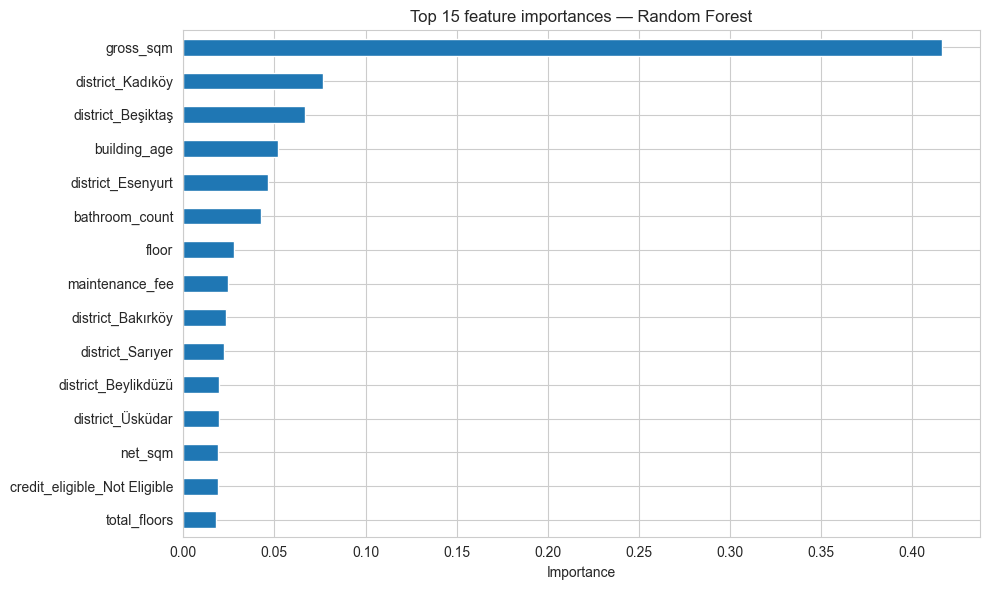

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 feature importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [14]:
location_cols = [c for c in X.columns if c.startswith("district_")]
size_cols = ["net_sqm", "gross_sqm"]

location_importance_sum = importances[location_cols].sum()
size_importance_sum = importances[size_cols].sum()

print(f"Summed importance — all district dummies : {location_importance_sum:.4f}")
print(f"Summed importance — net_sqm + gross_sqm   : {size_importance_sum:.4f}")


Summed importance — all district dummies : 0.3248
Summed importance — net_sqm + gross_sqm   : 0.4356


**Conclusion — this actually partially contradicts the EDA hypothesis, and that's a valuable finding in itself:** `gross_sqm` alone is the single most important feature (0.416), well above any individual district. Summed together, all district dummies combined (0.325) are still slightly **below** the combined importance of `net_sqm` + `gross_sqm` (0.436). So while location clearly matters (Kadıköy, Beşiktaş, and Esenyurt each rank in the top 5 individual features), **size remains the dominant single driver of price in this model** — the EDA's "location > size" hypothesis (Q13) is not confirmed once both effects compete directly inside one model. This is exactly why Q13 was phrased as a hypothesis rather than a conclusion. One more interesting note: `building_age` ranks 4th (0.052) despite showing ~zero linear correlation with price in the EDA (Q7) — a sign that its relationship with price is non-linear/interaction-based (e.g. only relevant combined with district), which only a tree-based model can pick up.

**Cross-reference with the EDA (Notebook 02):** after this notebook was first written, a closer look at Notebook 02's Q10 revealed that Bakırköy's #1 raw-price rank was mostly a size effect — its listings are simply bigger (median 160 m² vs. 95-120 m² in Beşiktaş/Kadıköy/Sarıyer), not a sign of higher location premium. That finding is fully consistent with what we see here: `gross_sqm`/`net_sqm` (size) outweighs all district dummies combined in feature importance, precisely because much of a district's raw price effect really is a size effect, which the model correctly attributes to the size features rather than to `district`. No changes were needed to the feature set itself — size and district were already modeled as separate variables, so the model naturally disentangled them.

## 7. Key Findings & Limitations

**Findings**
- Gradient Boosting is the best-performing baseline (R²=0.748, RMSE≈6.92M TRY on raw price), followed by Random Forest (R²=0.732), both clearly ahead of Linear Regression (R²=0.533) — real price relationships are non-linear.
- `gross_sqm` is the single strongest predictor (importance 0.416), consistent with Notebook 02's correlation findings.
- Location matters (several districts rank in the top features) but **does not outweigh size** once both compete in the same model — refining the EDA's Q13 hypothesis rather than confirming it outright.
- `building_age`, despite ~zero linear correlation in the EDA, ranks 4th in importance here — evidence of a non-linear or interactive effect invisible to simple correlation.

**Limitations of this first pass (important — this is a starting point, not a finished pipeline)**
- No hyperparameter tuning was done (default-ish parameters for Random Forest/Gradient Boosting).
- No cross-validation — a single train/test split (80/20) was used, so performance numbers have some variance not yet quantified.
- Missing-data handling was naive (median/`"Unknown"` imputation) — particularly weak for `floor_category` (~70% missing) and `maintenance_fee` (~64% missing); these columns deserve a more deliberate strategy or removal.
- `district` one-hot encoding creates a wide, sparse matrix (38 dummy columns) — target encoding or embeddings could work better, especially for linear models.
- No residual analysis was performed (e.g. checking whether errors are larger for certain districts, price ranges, or property types) — a natural next step before trusting these models further.

## 8. Next Steps

1. Add k-fold cross-validation to get robust performance estimates (not just one train/test split).
2. Hyperparameter tuning (grid/random search) for Random Forest and Gradient Boosting.
3. Reconsider `floor_category` and `maintenance_fee` — either drop them, or handle their heavy missingness more deliberately (e.g. missingness indicator features).
4. Try target/frequency encoding for `district` as an alternative to one-hot, especially to help the linear model.
5. Residual analysis: check whether prediction error is concentrated in specific districts, price segments, or property types (e.g. do luxury properties get systematically under/over-predicted?).
6. Only after the above: consider more advanced models (XGBoost/LightGBM) if the additional complexity is justified by a clear performance gain over Gradient Boosting.